# ETF Momentum: Protocol Parity Comparison

**Docker image**: `ml4t`

This notebook compares two implementations of the same ETF rotational momentum
strategy: a static weight-matrix calculation in the array-based style commonly
used with pandas (or libraries like VectorBT), and a sequential implementation in
`ml4t-backtest`.

The point is not to declare one framework "right" and the other "wrong". The
point is to show how specific protocol mismatches in timing, cash handling, and
cost treatment create measurable performance differences.

**Learning Objectives**:
- Compare an array-based implementation with a sequential implementation
- Quantify implementation divergence and catalog the protocol differences
- Separate library choice from modeling choice
- Use `PortfolioAnalysis` for consistent metric computation

**Book Reference**: Chapter 16, Section 16.3 (The Modern Backtesting Workbench)

**Prerequisites**: `01_backtest_first_principles` (ETF momentum protocol), `03_single_asset_vectorbt`, and `04_single_asset_ml4t_backtest`

## Two Simulation Styles

This notebook contrasts two common ways to apply the same target schedule:

| Implementation | Style | Strength | Watch Carefully |
|----------------|-------|----------|-----------------|
| **Weight matrix / pandas array-based** | Array-based | Fast research iteration, easy parameter broadcasting | Timing, execution price, and cost assumptions must be made explicit |
| **ml4t-backtest Engine** | Sequential | Explicit fills, cash, and broker state | Slower for large sweeps, more setup per run |

The array-based path below is a simple lagged-weight implementation. It should
not be read as a statement about the capabilities of VectorBT's portfolio
engine, which has richer execution semantics than plain array arithmetic. If you align
execution price, timing, and frictions more closely, the two implementations
can move much nearer to parity.

## Setup

In [1]:
"""ETF Momentum Protocol Parity - compare array and sequential implementations."""

'ETF Momentum Protocol Parity - compare array and sequential implementations.'

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.diagnostic.evaluation import PortfolioAnalysis

from data import load_etfs, load_macro
from utils.style import COLORS

In [3]:
# Production defaults - Papermill injects overrides after this cell
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
LOOKBACK_PERIOD = 126
TOP_N = 3
REGIME_THRESHOLD = 0.005
INITIAL_CASH = 100_000
ARRAY_TURNOVER_COST = 0.0005
ENGINE_COMMISSION = 0.0005
ENGINE_SLIPPAGE = 0.0005

## 1. Common Strategy and Explicit Frictions

The symbols and strategy parameters are common to both paths. Friction parameters
are separate because this is a divergence demonstration, not a cost-parity test.
The fixed ETF basket and current-vintage macro history make the result a
full-sample teaching comparison rather than an unbiased live estimate.

In [4]:
ETF_SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "AGG", "TLT", "GLD", "VNQ", "DBC"]

## 2. Load Common Data

In [5]:
etf_pl = load_etfs()
etf_pl = etf_pl.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
etf_pl = etf_pl.filter(
    (pl.col("symbol").is_in(ETF_SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
)
assert etf_pl.n_unique(["symbol", "timestamp"]) == len(etf_pl)
required_columns = ["timestamp", "symbol", "open", "high", "low", "close", "volume"]
assert set(required_columns) <= set(etf_pl.columns)
assert etf_pl.select(pl.all_horizontal(pl.col(required_columns).is_not_null()).all()).item()
assert etf_pl.select((pl.col("close") > 0).all()).item()
assert etf_pl.select((pl.col("volume") >= 0).all()).item()

Pivot the canonical long panel at the pandas boundary used by the array
implementation. Forward filling carries only observations already available.

In [6]:
close_prices_pl = etf_pl.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")
close_prices = close_prices_pl.to_pandas()
close_prices.set_index("timestamp", inplace=True)

available_symbols = [s for s in ETF_SYMBOLS if s in close_prices.columns]
close_prices = close_prices[available_symbols].ffill()
ETF_SYMBOLS = available_symbols
assert len(ETF_SYMBOLS) == 10
assert not close_prices.isna().any().any()

display(
    Markdown(
        f"The fixed teaching basket contains **{len(ETF_SYMBOLS)} ETFs** over "
        f"**{len(close_prices):,} daily observations** from "
        f"**{close_prices.index.min()} through {close_prices.index.max()}**."
    )
)

The fixed teaching basket contains **10 ETFs** over **3,522 daily observations** from **2010-01-04 00:00:00 through 2023-12-29 00:00:00**.

In [7]:
macro_df = load_macro()
assert macro_df.n_unique("timestamp") == len(macro_df)

if "YIELD_CURVE_SLOPE" in macro_df.columns:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), (pl.col("YIELD_CURVE_SLOPE") / 100).alias("slope")]
    ).drop_nulls()
    yield_curve_source = "YIELD_CURVE_SLOPE"
elif "DGS10" in macro_df.columns and "DGS2" in macro_df.columns:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), ((pl.col("DGS10") - pl.col("DGS2")) / 100).alias("slope")]
    ).drop_nulls()
    yield_curve_source = "DGS10 - DGS2"
else:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope")]
    ).drop_nulls()
    yield_curve_source = "dgs10 - dgs2"

yield_curve = yield_curve_pl.to_pandas().set_index("timestamp")
yield_curve_aligned = yield_curve.reindex(close_prices.index, method="ffill")
assert not yield_curve_aligned["slope"].isna().any()
regime = (yield_curve_aligned["slope"] > REGIME_THRESHOLD).astype(int)

display(
    Markdown(
        f"The regime uses the current-vintage **{yield_curve_source}** series and carries past "
        f"observations forward to ETF dates. The source contains **{len(yield_curve):,} dated "
        "observations**. This is a teaching comparison, not an ALFRED-vintage live simulation."
    )
)

The regime uses the current-vintage **YIELD_CURVE_SLOPE** series and carries past observations forward to ETF dates. The source contains **9,495 dated observations**. This is a teaching comparison, not an ALFRED-vintage live simulation.

## 3. Compute Momentum and Weights

In [8]:
daily_returns = close_prices.pct_change()
cumulative_return = close_prices.pct_change(LOOKBACK_PERIOD)
realized_vol = daily_returns.rolling(LOOKBACK_PERIOD).std() * np.sqrt(252)
momentum_score = cumulative_return / realized_vol
momentum_rank = momentum_score.rank(axis=1, ascending=False)

In [9]:
weights = pd.DataFrame(np.nan, index=close_prices.index, columns=ETF_SYMBOLS)
rebalance_dates = close_prices.loc[
    close_prices.index.isin(
        close_prices.groupby(close_prices.index.to_period("M")).apply(lambda x: x.index[-1])
    )
].index

first_valid_momentum = momentum_rank.dropna(how="all").index[0]
first_day = close_prices.index[0]
weights.loc[first_day, :] = 0.0
weights.loc[first_day, "AGG"] = 0.60
weights.loc[first_day, "TLT"] = 0.40

for date in rebalance_dates:
    weights.loc[date, :] = 0.0
    if date < first_valid_momentum or date not in momentum_rank.index:
        weights.loc[date, "AGG"] = 0.60
        weights.loc[date, "TLT"] = 0.40
        continue

    if regime.loc[date] == 1:
        ranks = momentum_rank.loc[date]
        top_n_etfs = ranks[ranks <= TOP_N].index.tolist()
        weight = 1.0 / len(top_n_etfs) if len(top_n_etfs) > 0 else 0
        for etf in top_n_etfs:
            weights.loc[date, etf] = weight
    else:
        weights.loc[date, "AGG"] = 0.60
        weights.loc[date, "TLT"] = 0.40

weights = weights.ffill()
assert not weights.isna().any().any()
np.testing.assert_allclose(weights.sum(axis=1).to_numpy(), 1.0, rtol=0, atol=1e-12)

## 4. Array-Based Simulation

The calculation below is a compact parity reference built from lagged target
weights and close-to-close returns - a plain array-based backtest using
pandas arithmetic, not VectorBT's portfolio engine. It is intentionally
simple. The resulting gap versus the sequential engine reflects this
notebook's implementation choices, not a blanket limit of any one library.

In [10]:
shifted_weights_vbt = weights.shift(1).fillna(0)
returns_vbt = close_prices.pct_change().fillna(0)
portfolio_returns_vbt = (shifted_weights_vbt * returns_vbt).sum(axis=1)

# A target chosen at t is executed for the t+1 return interval.
target_turnover = weights.diff().fillna(weights).abs().sum(axis=1)
executed_turnover = target_turnover.shift(1).fillna(0)
cost_drag = executed_turnover * ARRAY_TURNOVER_COST

portfolio_returns_vbt_net = portfolio_returns_vbt - cost_drag
equity_vbt = INITIAL_CASH * (1 + portfolio_returns_vbt_net).cumprod()

display(
    Markdown(
        f"The array approximation ends at **${equity_vbt.iloc[-1]:,.0f}** after charging "
        f"**{ARRAY_TURNOVER_COST * 10_000:.0f} bps** on scheduled target turnover. "
        "Carried targets enter the "
        "daily return arithmetic without modeling shares or cash."
    )
)

The array approximation ends at **$322,113** after charging **5 bps** on scheduled target turnover. Carried targets enter the daily return arithmetic without modeling shares or cash.

## 5. Sequential Engine Simulation

The Engine processes data bar by bar through a `Strategy` class. We pass the
same precomputed target weights via `context_df` so the signal logic stays
aligned and only the execution mechanics differ.

In [11]:
class WeightRebalanceStrategy(Strategy):
    """Rebalance to precomputed target weights from context.

    Uses broker.rebalance_to_weights() - the Engine handles position
    sizing, order generation, and fill simulation internally.
    """

    def __init__(self, assets):
        self.assets = assets

    def on_data(self, timestamp, data, context, broker):
        target_weights = {}
        for asset in self.assets:
            w = context.get(f"w_{asset}", 0.0)
            if w is not None and not np.isnan(w):
                target_weights[asset] = w
        broker.rebalance_to_weights(target_weights)

In [12]:
# Prepare data for ml4t-backtest Engine (requires long-format prices)
etf_long = etf_pl.select(
    [
        "timestamp",
        "symbol",
        "open",
        "high",
        "low",
        "close",
        "volume",
    ]
)

# Build context_df with target weights per timestamp
weight_records = []
for date in weights.index:
    row = {"timestamp": pd.Timestamp(date)}
    for sym in ETF_SYMBOLS:
        w = weights.loc[date, sym]
        row[f"w_{sym}"] = float(w) if not np.isnan(w) else 0.0
    weight_records.append(row)

context_df = pl.DataFrame(weight_records).with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
# Align context timestamps with price timestamps
etf_long = etf_long.with_columns(pl.col("timestamp").cast(pl.Datetime("us")))

In [13]:
# Run ml4t-backtest Engine
feed = DataFeed(prices_df=etf_long, context_df=context_df)
strategy = WeightRebalanceStrategy(assets=ETF_SYMBOLS)

config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    commission_rate=ENGINE_COMMISSION,
    slippage_rate=ENGINE_SLIPPAGE,
    calendar="NYSE",
)
engine = Engine(feed=feed, strategy=strategy, config=config)

results_ml4t = engine.run()

ec_ml4t = results_ml4t["equity"]
equity_ml4t = pd.Series(
    ec_ml4t.values, index=[t.date() if hasattr(t, "timestamp") else t for t in ec_ml4t.timestamps]
)
portfolio_returns_ml4t = equity_ml4t.pct_change().dropna()

display(
    Markdown(
        f"The sequential account ends at **${equity_ml4t.iloc[-1]:,.0f}** with "
        f"**{ENGINE_COMMISSION * 10_000:.0f} bps commission** and "
        f"**{ENGINE_SLIPPAGE * 10_000:.0f} bps slippage** applied to submitted trades. It "
        "restores carried targets through actual shares and cash."
    )
)

The sequential account ends at **$286,320** with **5 bps commission** and **5 bps slippage** applied to submitted trades. It restores carried targets through actual shares and cash.

Align both return streams before computing any comparison statistic. This
removes date-set differences from the framework comparison.

In [14]:
array_returns = portfolio_returns_vbt_net.copy()
engine_returns = portfolio_returns_ml4t.copy()
array_returns.index = pd.to_datetime(array_returns.index)
engine_returns.index = pd.to_datetime(engine_returns.index)
comparison_returns = pd.concat(
    {"array_based": array_returns, "ml4t_backtest": engine_returns}, axis=1, join="inner"
).dropna()
assert comparison_returns.index.is_unique
assert not comparison_returns.isna().any().any()

## 6. Parity Comparison via PortfolioAnalysis

Using `PortfolioAnalysis` ensures consistent metric computation across
frameworks - the same functions compute Sharpe, drawdown, etc. regardless
of the backtest engine that produced the returns.

In [15]:
vbt_analysis = PortfolioAnalysis(
    returns=comparison_returns["array_based"].to_numpy(), periods_per_year=252
)
ml4t_analysis = PortfolioAnalysis(
    returns=comparison_returns["ml4t_backtest"].to_numpy(), periods_per_year=252
)

vbt_stats = vbt_analysis.compute_summary_stats()
ml4t_stats = ml4t_analysis.compute_summary_stats()

metrics_labels = [
    "Total Return (%)",
    "CAGR (%)",
    "Volatility (%)",
    "Sharpe",
    "Sortino",
    "Max Drawdown (%)",
]
metric_scales = [100, 100, 100, 1, 1, 100]
vbt_vals = [
    vbt_stats.total_return,
    vbt_stats.annual_return,
    vbt_stats.annual_volatility,
    vbt_stats.sharpe_ratio,
    vbt_stats.sortino_ratio,
    vbt_stats.max_drawdown,
]
ml4t_vals = [
    ml4t_stats.total_return,
    ml4t_stats.annual_return,
    ml4t_stats.annual_volatility,
    ml4t_stats.sharpe_ratio,
    ml4t_stats.sortino_ratio,
    ml4t_stats.max_drawdown,
]

The table uses the same common-date returns and the same metric implementation.
Execution and friction assumptions remain intentionally different.

In [16]:
parity_df = pl.DataFrame(
    {
        "metric": metrics_labels,
        "array_based": [float(v) * scale for v, scale in zip(vbt_vals, metric_scales, strict=True)],
        "ml4t_backtest": [
            float(value) * scale for value, scale in zip(ml4t_vals, metric_scales, strict=True)
        ],
        "array_minus_engine": [
            (float(vbt) - float(engine)) * scale
            for vbt, engine, scale in zip(vbt_vals, ml4t_vals, metric_scales, strict=True)
        ],
    }
)
parity_df

metric,array_based,ml4t_backtest,array_minus_engine
str,f64,f64,f64
"""Total Return (%)""",222.113161,186.319587,35.793574
"""CAGR (%)""",8.732271,7.819445,0.912826
"""Volatility (%)""",11.337563,11.335295,0.002268
"""Sharpe""",0.795322,0.721063,0.074259
"""Sortino""",0.748544,0.678298,0.070247
"""Max Drawdown (%)""",-31.876727,-31.548045,-0.328682


In [17]:
vbt_total = vbt_stats.total_return
ml4t_total = ml4t_stats.total_return
rel_diff = abs(vbt_total - ml4t_total) / max(abs(vbt_total), 0.0001)
ending_gap = float(equity_vbt.iloc[-1] - equity_ml4t.iloc[-1])
correlation = comparison_returns.corr().iloc[0, 1]
display(
    Markdown(
        f"Across **{len(comparison_returns):,} common daily returns**, correlation is "
        f"**{correlation:.4f}**. The total-return estimates differ by **{rel_diff:.1%}** "
        f"relative to the array estimate, and ending equity differs by **${ending_gap:,.0f}**. "
        "The comparison measures the joint effect of the declared protocol differences; it does "
        "not identify a causal share for any one mechanism."
    )
)

Across **3,521 common daily returns**, correlation is **0.9968**. The total-return estimates differ by **16.1%** relative to the array estimate, and ending equity differs by **$35,794**. The comparison measures the joint effect of the declared protocol differences; it does not identify a causal share for any one mechanism.

The high daily correlation shows that the paths respond similarly to the common
target schedule. It does not prove protocol parity: execution price, friction
accounting, share quantization, and cash treatment remain different by design.
Notebook 07 isolates such mechanisms one at a time.

## 7. Visualize Equity Curves

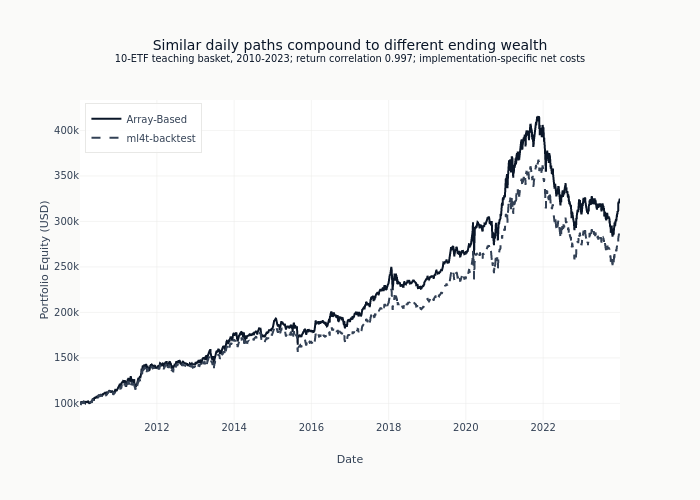

In [18]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=equity_vbt.index,
        y=equity_vbt,
        name="Array-Based",
        line=dict(color=COLORS["blue"], width=2),
    )
)

fig.add_trace(
    go.Scatter(
        x=equity_ml4t.index,
        y=equity_ml4t,
        name="ml4t-backtest",
        line=dict(color=COLORS["neutral"], width=2, dash="dash"),
    )
)

fig.update_layout(
    title=(
        "Similar daily paths compound to different ending wealth"
        f"<br><sup>10-ETF teaching basket, 2010-2023; return correlation {correlation:.3f}; "
        "implementation-specific net costs</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Portfolio Equity (USD)",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

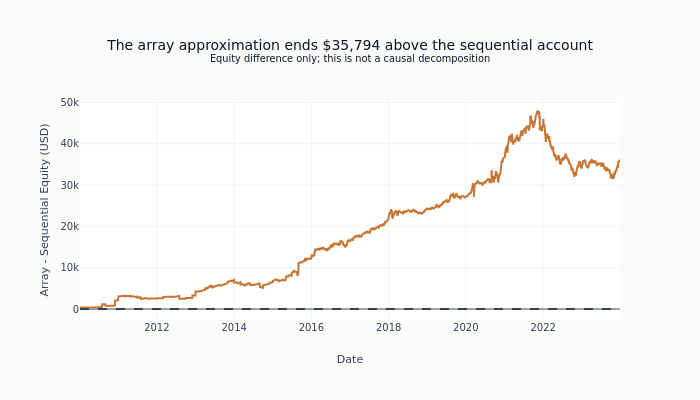

In [19]:
# Difference over time (align index types)
eq_vbt_dt = equity_vbt.copy()
eq_ml4t_dt = equity_ml4t.copy()
eq_vbt_dt.index = pd.to_datetime(eq_vbt_dt.index)
eq_ml4t_dt.index = pd.to_datetime(eq_ml4t_dt.index)
shared_eq = eq_vbt_dt.index.intersection(eq_ml4t_dt.index)
diff_series = eq_vbt_dt.loc[shared_eq] - eq_ml4t_dt.loc[shared_eq]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=diff_series.index,
        y=diff_series,
        name="Array - ml4t",
        line=dict(color=COLORS["copper"], width=2),
    )
)

fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])

fig.update_layout(
    title=(
        f"The array approximation ends ${ending_gap:,.0f} above the sequential account"
        "<br><sup>Equity difference only; this is not a causal decomposition</sup>"
    ),
    xaxis_title="Date",
    yaxis_title="Array - Sequential Equity (USD)",
    height=400,
)
fig.show()

## 8. Sources of Differences

| Aspect | Array-Based Path | Sequential Path |
|---|---|---|
| Execution Timing | Prior target applied to close-to-close return | Order fills at next-bar open |
| Cost Model | 5 bps on scheduled target turnover | 5 bps commission + 5 bps slippage on submitted trades |
| Position Tracking | Daily target-weight return approximation | Integer shares + explicit cash |
| Cash Management | Implicit | Explicit cash tracking |
| Target Maintenance | Carried target enters daily arithmetic | Daily callback restores carried target through orders |

These differences arise from the specific protocol choices used in this
notebook, not from "vectorized versus event-driven" as abstract categories.
The observed divergence is compatible with these differences, but this
notebook does not estimate their separate contributions. Notebook 07 performs
the controlled decomposition needed for causal attribution.

## 9. Correlation of Returns

In [20]:
display(
    Markdown(
        f"The common-date daily returns have **{correlation:.4f} correlation**. This supports "
        "the narrow claim that both paths respond similarly to the target schedule. It does not "
        "show that their fills, costs, holdings, or ending wealth are interchangeable."
    )
)

The common-date daily returns have **0.9968 correlation**. This supports the narrow claim that both paths respond similarly to the target schedule. It does not show that their fills, costs, holdings, or ending wealth are interchangeable.

Correlation is a path-similarity diagnostic, not a parity verdict. A high value
can coexist with a material compounded wealth gap, as the two figures show.

## 10. Framework Selection Guide

| Research Need | Convenient First Representation | Why |
|---------------|--------------------------------|-----|
| Parameter sweeps (100+ combos) | Array-based | Fast broadcasting over grids |
| Signal screening | Array-based | Rapid hypothesis filtering |
| Single-protocol parity audit | Either, but align assumptions first | The protocol matters more than the library label |
| Complex order logic | Sequential | Stops, contingencies, and state updates are explicit |
| Short selling / margin | Sequential | Accounting and constraints stay visible |
| Final validation | The implementation that matches the intended execution protocol | No framework wins by default |

For this ETF momentum strategy, both styles can be made comparable once
execution timing and frictions are aligned. The main lesson is to define the
trading protocol first, then choose the implementation style that makes that
protocol easiest to compute and audit.

## Key Takeaways

1. **This notebook compares two implementations of the same strategy**, not
   two immutable categories of truth.

2. **Divergence here reflects timing, cost, and cash-handling choices in this
   notebook**. Audit the protocol before inferring a library limitation.

3. **Consistent metrics matter**: Using `PortfolioAnalysis` for both paths
   ensures Sharpe, drawdown, and other metrics are computed identically.

4. **Array-based research code is attractive when the protocol can be
   precomputed and speed matters**. Sequential simulation is attractive when
   state, order handling, or broker accounting are central to the question.

5. **Do not treat the sequential result as automatically correct**. Trust the
   implementation that best matches the execution protocol you intend to test.

**Next**: `07_engine_divergence_anatomy` decomposes execution differences under controlled changes.
**Book**: Section 16.3 covers the speed-fidelity spectrum in depth.